# FILE 2 — How much of "domain shift" is just preprocessing?

Reads `preprocess_variants_findings.csv` from **FILE 1**: the same OAI knees, pushed through four preprocessing
pipelines, scored by one frozen model.

Because the knee, the label, and the model weights are all held fixed, **every difference below is caused by
preprocessing alone.** No patient difference. No scanner difference. No grader difference. No prevalence
difference. That control is what makes the claim strong.

### What each part asks
| Part | Question |
|---|---|
| A | Does the CLAHE/resize **order** change the grade? By how much? |
| B | Does it corrupt the **clinical findings** (osteophyte / JSN / sclerosis) — the CBM bottleneck? |
| C | How does the preprocessing penalty compare to the **cross-cohort gap** you attributed to domain shift? |
| D | Are the errors **systematic** (a bias you could correct) or random noise? |

`oai_order` is the reference: it reproduces the pipeline your OAI images actually went through.

In [ ]:
import os, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, accuracy_score
from itertools import combinations

SEARCH = ["/content/drive/MyDrive/Master Thesis/scope3_mt/results",
          "/mnt/user-data/uploads", ".", "./results"]
FEATS  = ["osteophyte", "jsn", "sclerosis"]
REFERENCE = "oai_order"      # the pipeline your real OAI images went through
MISSING_SENTINEL = -1

try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception: pass

def find_csv():
    for d in SEARCH:
        p = os.path.join(d, "preprocess_variants_findings.csv")
        if os.path.exists(p): return p
    raise FileNotFoundError("preprocess_variants_findings.csv not found. Run FILE 1 first. Searched: %s" % SEARCH)

path = find_csv(); print("reading:", path)
df = pd.read_csv(path)
VARIANTS = sorted({c.split("__")[0] for c in df.columns if "__" in c})
print("variants found:", VARIANTS)
print("knees:", len(df), "| label distribution:", dict(df.kl_label.value_counts().sort_index()))
assert REFERENCE in VARIANTS, f"{REFERENCE} missing from {VARIANTS}"
df.head()

Mounted at /content/drive
reading: /content/drive/MyDrive/Master Thesis/scope3_mt/results/preprocess_variants_findings.csv
variants found: ['double_clahe', 'mrkr_order', 'no_clahe', 'oai_order']
knees: 1444 | label distribution: {0: np.int64(583), 1: np.int64(239), 2: np.int64(384), 3: np.int64(194), 4: np.int64(44)}


,subject_id,side,knee_key,kl_label,osteophyte_true,jsn_true,sclerosis_true,oai_order__kl_pred,oai_order__osteophyte_pred,oai_order__jsn_pred,...,mrkr_order__jsn_pred,mrkr_order__sclerosis_pred,double_clahe__kl_pred,double_clahe__osteophyte_pred,double_clahe__jsn_pred,double_clahe__sclerosis_pred,no_clahe__kl_pred,no_clahe__osteophyte_pred,no_clahe__jsn_pred,no_clahe__sclerosis_pred
0,9001104,R,9001104R,3,2.0,2.0,2.0,3,1,2,...,2,1,3,1,2,2,3,1,2,2
1,9001897,R,9001897R,3,1.0,2.0,2.0,3,1,2,...,2,1,2,1,2,1,3,1,2,2
2,9001897,L,9001897L,0,0.0,0.0,0.0,2,0,0,...,0,0,0,0,0,0,2,0,0,0
3,9002411,L,9002411L,2,1.0,1.0,1.0,2,1,0,...,0,0,2,1,0,0,2,1,0,0
4,9002430,L,9002430L,3,1.0,2.0,2.0,3,3,2,...,2,1,3,1,2,2,3,3,2,2


In [ ]:
def qwk(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = ~(pd.isna(a) | pd.isna(b))
    if m.sum() == 0: return np.nan
    k = cohen_kappa_score(a[m].astype(int), b[m].astype(int), weights="quadratic", labels=[0,1,2,3,4])
    return 0.0 if np.isnan(k) else k

def acc(a, b):
    a, b = np.asarray(a), np.asarray(b)
    m = ~(pd.isna(a) | pd.isna(b))
    return np.nan if m.sum() == 0 else accuracy_score(a[m].astype(int), b[m].astype(int))

C_MAP = {"oai_order":"#2a7fb8", "mrkr_order":"#8a5cb0", "double_clahe":"#c44e52", "no_clahe":"#999999"}
LABEL = {"oai_order":"OAI order\n(CLAHE→resize)", "mrkr_order":"MRKR order\n(resize→CLAHE)",
         "double_clahe":"double CLAHE\n(Mendeley-like)", "no_clahe":"no CLAHE\n(control)"}
print("helpers ready")

helpers ready


## Part A — does the pipeline order change the grade?

Two readings, and they answer different questions:
- **vs ground truth** — does the wrong order actually cost accuracy?
- **vs the reference pipeline** — how often does the *same model* flip its own answer on the *same knee* purely
  because the image was processed in a different order? That is the self-contradiction number, and it needs no
  ground truth at all to be alarming.

,acc_vs_truth,qwk_vs_truth,agree_with_reference,qwk_with_reference,acc_drop_vs_reference,qwk_drop_vs_reference
variant,,,,,,
double_clahe,0.688,0.800,0.886,0.899,0.054,0.066
mrkr_order,0.618,0.709,0.779,0.780,0.124,0.156
no_clahe,0.727,0.854,0.894,0.906,0.015,0.012
oai_order,0.742,0.866,1.000,1.000,0.000,0.000


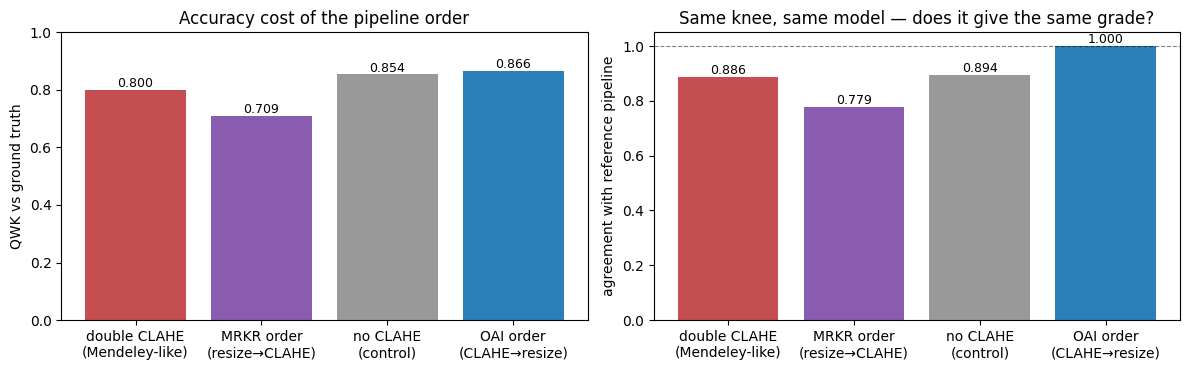

Right-hand panel is the headline: anything below 1.0 is the model contradicting ITSELF on the
identical knee, purely because two of your own scripts order CLAHE and resize differently.


In [ ]:
rows = []
for v in VARIANTS:
    p = df[f"{v}__kl_pred"]
    rows.append(dict(variant=v,
                     acc_vs_truth=acc(df.kl_label, p), qwk_vs_truth=qwk(df.kl_label, p),
                     agree_with_reference=acc(df[f"{REFERENCE}__kl_pred"], p),
                     qwk_with_reference=qwk(df[f"{REFERENCE}__kl_pred"], p)))
A = pd.DataFrame(rows).set_index("variant").loc[[v for v in VARIANTS]]
A["acc_drop_vs_reference"] = A.loc[REFERENCE, "acc_vs_truth"] - A["acc_vs_truth"]
A["qwk_drop_vs_reference"] = A.loc[REFERENCE, "qwk_vs_truth"] - A["qwk_vs_truth"]
display(A.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.bar([LABEL[v] for v in VARIANTS], [A.loc[v,"qwk_vs_truth"] for v in VARIANTS],
       color=[C_MAP.get(v,"#888") for v in VARIANTS])
for i, v in enumerate(VARIANTS): ax.text(i, A.loc[v,"qwk_vs_truth"]+.01, "%.3f"%A.loc[v,"qwk_vs_truth"], ha="center", fontsize=9)
ax.set_ylabel("QWK vs ground truth"); ax.set_ylim(0,1); ax.set_title("Accuracy cost of the pipeline order")
ax = axes[1]
ax.bar([LABEL[v] for v in VARIANTS], [A.loc[v,"agree_with_reference"] for v in VARIANTS],
       color=[C_MAP.get(v,"#888") for v in VARIANTS])
ax.axhline(1.0, ls="--", lw=.8, color="k", alpha=.5)
for i, v in enumerate(VARIANTS): ax.text(i, A.loc[v,"agree_with_reference"]+.01, "%.3f"%A.loc[v,"agree_with_reference"], ha="center", fontsize=9)
ax.set_ylabel("agreement with reference pipeline"); ax.set_ylim(0,1.05)
ax.set_title("Same knee, same model — does it give the same grade?")
plt.tight_layout(); plt.show()

print("Right-hand panel is the headline: anything below 1.0 is the model contradicting ITSELF on the")
print("identical knee, purely because two of your own scripts order CLAHE and resize differently.")

## Part B — does it corrupt the clinical findings?

This is the CBM bottleneck. If the findings are damaged, everything downstream inherits it — which is exactly
what the intervention experiment showed (Mendeley 0.370 → 0.890 once given true findings).

,osteophyte_agree_ref,osteophyte_qwk_truth,jsn_agree_ref,jsn_qwk_truth,sclerosis_agree_ref,sclerosis_qwk_truth
variant,,,,,,
double_clahe,0.893,0.679,0.909,0.836,0.940,0.761
mrkr_order,0.803,0.561,0.842,0.783,0.892,0.708
no_clahe,0.922,0.708,0.920,0.845,0.945,0.813
oai_order,1.000,0.726,1.000,0.856,1.000,0.813


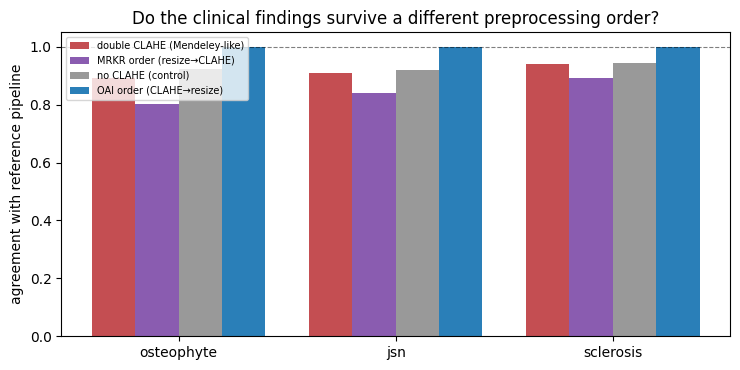

In [ ]:
rows = []
for v in VARIANTS:
    r = {"variant": v}
    for f in FEATS:
        col = f"{v}__{f}_pred"
        if col not in df.columns: continue
        r[f"{f}_agree_ref"] = acc(df[f"{REFERENCE}__{f}_pred"], df[col])
        tcol = f"{f}_true"
        if tcol in df.columns:
            m = df[tcol].notna() & (df[tcol] != MISSING_SENTINEL)
            r[f"{f}_qwk_truth"] = qwk(df.loc[m, tcol], df.loc[m, col]) if m.sum() > 20 else np.nan
    rows.append(r)
B = pd.DataFrame(rows).set_index("variant")
display(B.round(3))

present = [f for f in FEATS if f"{f}_agree_ref" in B.columns]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(present)); w = 0.8/len(VARIANTS)
for i, v in enumerate(VARIANTS):
    ax.bar(x + i*w, [B.loc[v, f"{f}_agree_ref"] for f in present], w,
           label=LABEL[v].replace("\n"," "), color=C_MAP.get(v,"#888"))
ax.set_xticks(x + w*(len(VARIANTS)-1)/2); ax.set_xticklabels(present)
ax.axhline(1.0, ls="--", lw=.8, color="k", alpha=.5); ax.set_ylim(0,1.05)
ax.set_ylabel("agreement with reference pipeline"); ax.legend(fontsize=7)
ax.set_title("Do the clinical findings survive a different preprocessing order?")
plt.tight_layout(); plt.show()

## Part C — the money comparison

Put the preprocessing penalty next to the cross-cohort gap you have been calling domain shift.

Fill in `OBSERVED` from your ceiling-notebook run (the numbers already in hand). The question this answers:
**how much of that gap is explained by preprocessing alone, on identical knees?**

=== preprocessing-only penalty (identical knees, identical labels, one model) ===
  double_clahe   QWK 0.800  (-0.066 vs oai_order)
  mrkr_order     QWK 0.709  (-0.156 vs oai_order)
  no_clahe       QWK 0.854  (-0.012 vs oai_order)

=== the cross-cohort gap you observed ===
  OAI 0.794  vs  Mendeley 0.370   ->  gap = 0.424 QWK

  double-CLAHE penalty (preprocessing ONLY): 0.066 QWK
  share of the observed cross-cohort gap explained by preprocessing alone: 15%

  >>> The remainder is everything else combined: fold/training differences, Chen's own
  >>> upstream processing, and any genuine population effect. Report the split honestly --
  >>> even 'preprocessing explains a third of it' is a strong, quotable claim.


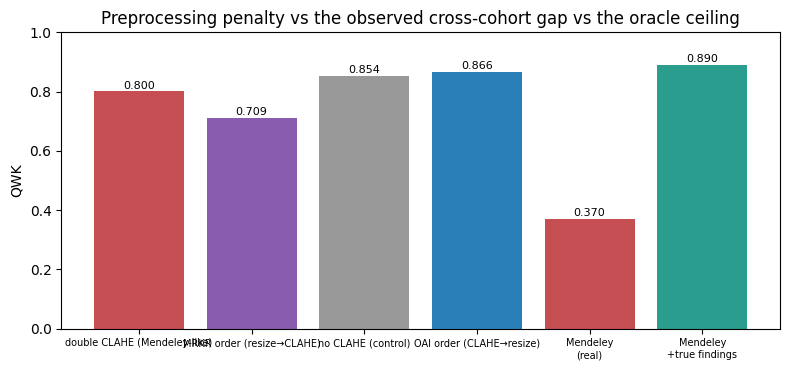

In [ ]:
# From your ceiling notebook (Part 5 + Part 4). Edit if your reruns change them.
OBSERVED = {
    "OAI (packed pipeline, real run)":       0.794,   # intervention curve, 0% intervened
    "Mendeley (packed pipeline, real run)":  0.370,   # intervention curve, 0% intervened
    "Mendeley with TRUE findings (ceiling)": 0.890,   # intervention curve, 100% intervened
}
ref_q = A.loc[REFERENCE, "qwk_vs_truth"]
print("=== preprocessing-only penalty (identical knees, identical labels, one model) ===")
for v in VARIANTS:
    if v == REFERENCE: continue
    print("  %-14s QWK %.3f  (%+.3f vs %s)" % (v, A.loc[v,"qwk_vs_truth"], A.loc[v,"qwk_vs_truth"]-ref_q, REFERENCE))

gap = OBSERVED["OAI (packed pipeline, real run)"] - OBSERVED["Mendeley (packed pipeline, real run)"]
print("\n=== the cross-cohort gap you observed ===")
print("  OAI %.3f  vs  Mendeley %.3f   ->  gap = %.3f QWK" %
      (OBSERVED["OAI (packed pipeline, real run)"], OBSERVED["Mendeley (packed pipeline, real run)"], gap))

pp_pen = ref_q - A.loc["double_clahe", "qwk_vs_truth"] if "double_clahe" in A.index else np.nan
if not np.isnan(pp_pen) and gap > 0:
    print("\n  double-CLAHE penalty (preprocessing ONLY): %.3f QWK" % pp_pen)
    print("  share of the observed cross-cohort gap explained by preprocessing alone: %.0f%%" % (100*pp_pen/gap))
    print("\n  >>> The remainder is everything else combined: fold/training differences, Chen's own")
    print("  >>> upstream processing, and any genuine population effect. Report the split honestly --")
    print("  >>> even 'preprocessing explains a third of it' is a strong, quotable claim.")

fig, ax = plt.subplots(figsize=(8, 3.8))
names = [LABEL[v].replace("\n"," ") for v in VARIANTS] + ["Mendeley\n(real)", "Mendeley\n+true findings"]
vals  = [A.loc[v,"qwk_vs_truth"] for v in VARIANTS] + [OBSERVED["Mendeley (packed pipeline, real run)"],
                                                       OBSERVED["Mendeley with TRUE findings (ceiling)"]]
cols  = [C_MAP.get(v,"#888") for v in VARIANTS] + ["#c44e52", "#2a9d8f"]
ax.bar(names, vals, color=cols)
for i, v in enumerate(vals): ax.text(i, v+.01, "%.3f"%v, ha="center", fontsize=8)
ax.set_ylabel("QWK"); ax.set_ylim(0,1)
ax.set_title("Preprocessing penalty vs the observed cross-cohort gap vs the oracle ceiling")
plt.xticks(fontsize=7); plt.tight_layout(); plt.show()

## Part D — systematic or random?

A **systematic** shift (consistent direction) is correctable — you could recalibrate or simply re-run the
pipeline. **Random** damage is not. This decides whether the finding comes with a fix or only a warning.

,kl_mean_shift,kl_sd,kl_mae,osteophyte_shift,osteophyte_sd,jsn_shift,jsn_sd,sclerosis_shift,sclerosis_sd
variant,,,,,,,,,
double_clahe,-0.163,0.537,0.181,-0.120,0.407,-0.065,0.298,-0.048,0.248
mrkr_order,-0.256,0.782,0.370,-0.204,0.547,-0.096,0.434,-0.078,0.351
no_clahe,0.098,0.544,0.172,0.048,0.357,0.034,0.280,0.033,0.232


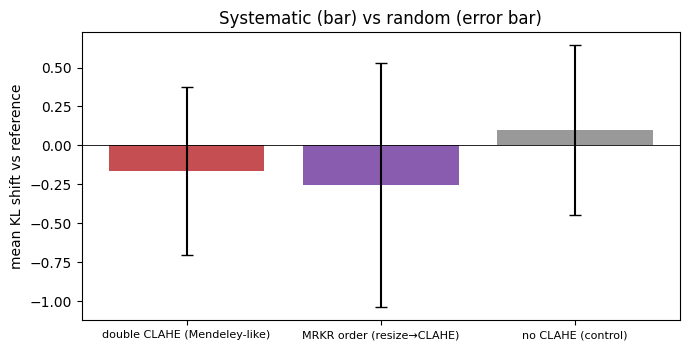

Bar far from 0 with a small error bar -> systematic and CORRECTABLE.
Bar near 0 with a large error bar    -> random damage; no recalibration will fix it.


In [ ]:
rows = []
for v in VARIANTS:
    if v == REFERENCE: continue
    d = df[f"{v}__kl_pred"] - df[f"{REFERENCE}__kl_pred"]
    r = {"variant": v, "kl_mean_shift": d.mean(), "kl_sd": d.std(), "kl_mae": d.abs().mean()}
    for f in FEATS:
        col, rcol = f"{v}__{f}_pred", f"{REFERENCE}__{f}_pred"
        if col in df.columns:
            dd = df[col] - df[rcol]
            r[f"{f}_shift"] = dd.mean(); r[f"{f}_sd"] = dd.std()
    rows.append(r)
D = pd.DataFrame(rows).set_index("variant")
display(D.round(3))

fig, ax = plt.subplots(figsize=(7, 3.6))
vs = [v for v in VARIANTS if v != REFERENCE]
ax.bar([LABEL[v].replace("\n"," ") for v in vs], [D.loc[v,"kl_mean_shift"] for v in vs],
       yerr=[D.loc[v,"kl_sd"] for v in vs], capsize=4, color=[C_MAP.get(v,"#888") for v in vs])
ax.axhline(0, color="k", lw=.6); ax.set_ylabel("mean KL shift vs reference")
ax.set_title("Systematic (bar) vs random (error bar)")
plt.xticks(fontsize=8); plt.tight_layout(); plt.show()
print("Bar far from 0 with a small error bar -> systematic and CORRECTABLE.")
print("Bar near 0 with a large error bar    -> random damage; no recalibration will fix it.")